# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

import os
import matplotlib.pyplot as plt
import datetime as dt

from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.preprocessing import MinMaxScaler

2024-05-04 12:38:51.302059: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-04 12:38:51.346725: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-04 12:38:51.346766: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-04 12:38:51.347711: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-05-04 12:38:51.354747: I tensorflow/core/platform/cpu_feature_guar

# Load Data

In [2]:
df = pd.read_csv('./Starbucks_stock_history.csv')
df.drop(columns=['Dividends', 'Stock Splits'], inplace=True)
df.head()


,Date,Open,High,Low,Close,Volume
0,1992-06-26,0.270957,0.287086,0.264507,0.277409,224358400
1,1992-06-29,0.280635,0.303215,0.274183,0.296763,58732800
2,1992-06-30,0.303215,0.306440,0.283860,0.287086,34777600
3,1992-07-01,0.290312,0.296763,0.280635,0.293538,18316800
4,1992-07-02,0.296763,0.296763,0.287086,0.293538,13996800


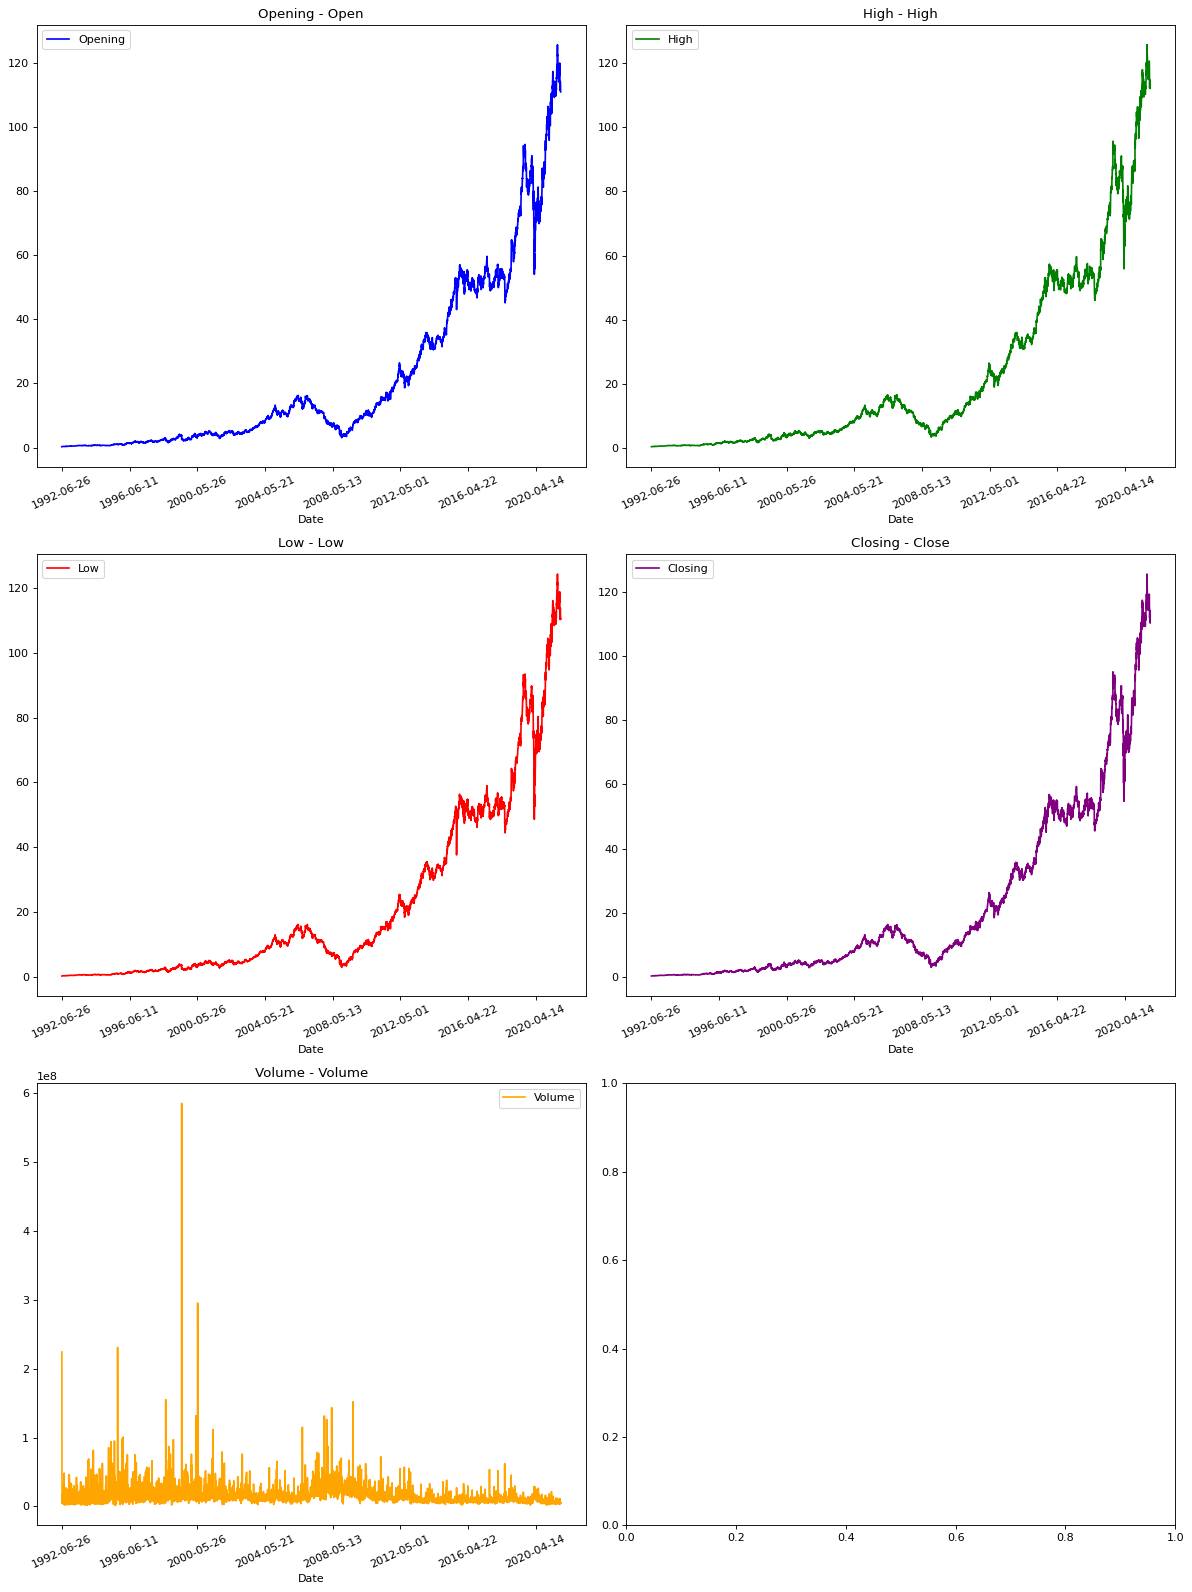

In [3]:
feature_keys = ["Open", "High", "Low", "Close", "Volume"]
titles = ["Opening", "High", "Low", "Closing", "Volume"]
colors = ["blue", "green", "red", "purple", "orange"]


def show_raw_visualization(data):
    time_data = data['Date']
    fig, axes = plt.subplots(
        nrows=3, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k"
    )
    for i in range(len(feature_keys)):
        key = feature_keys[i]
        c = colors[i % (len(colors))]
        t_data = data[key]
        t_data.index = time_data
        t_data.head()
        ax = t_data.plot(
            ax=axes[i // 2, i % 2],
            color=c,
            title="{} - {}".format(titles[i], key),
            rot=25,
        )
        ax.legend([titles[i]])
    plt.tight_layout()
    plt.show()


show_raw_visualization(df)

From the plot, the data is a timeseries data with a general rough uptrend over time for Open, High, Low, Close Stock Price. THe volume of the stock is generally stable over time.

# Preprocess Model

## Split the data into training and testing set

In [4]:
n=len(df)
train_split = (n//20)*19
step = 1
past = (n//20)*15 # 5 years
future = 30 # 30 days

learning_rate = 0.001
batch_size = 16
epochs = 1000

In [5]:
df_train=df[(n//20)*15:(n//20)*19]
df_test=df[(n//20)*19:]

Split the data into training set and testing set. Using time series split, using data from 2014 to 2019 as training set and data from 2020 to 2021 as testing set.

In [6]:
len(df), len(df_train), len(df_test)

(7372, 1472, 380)

### Visualize the split

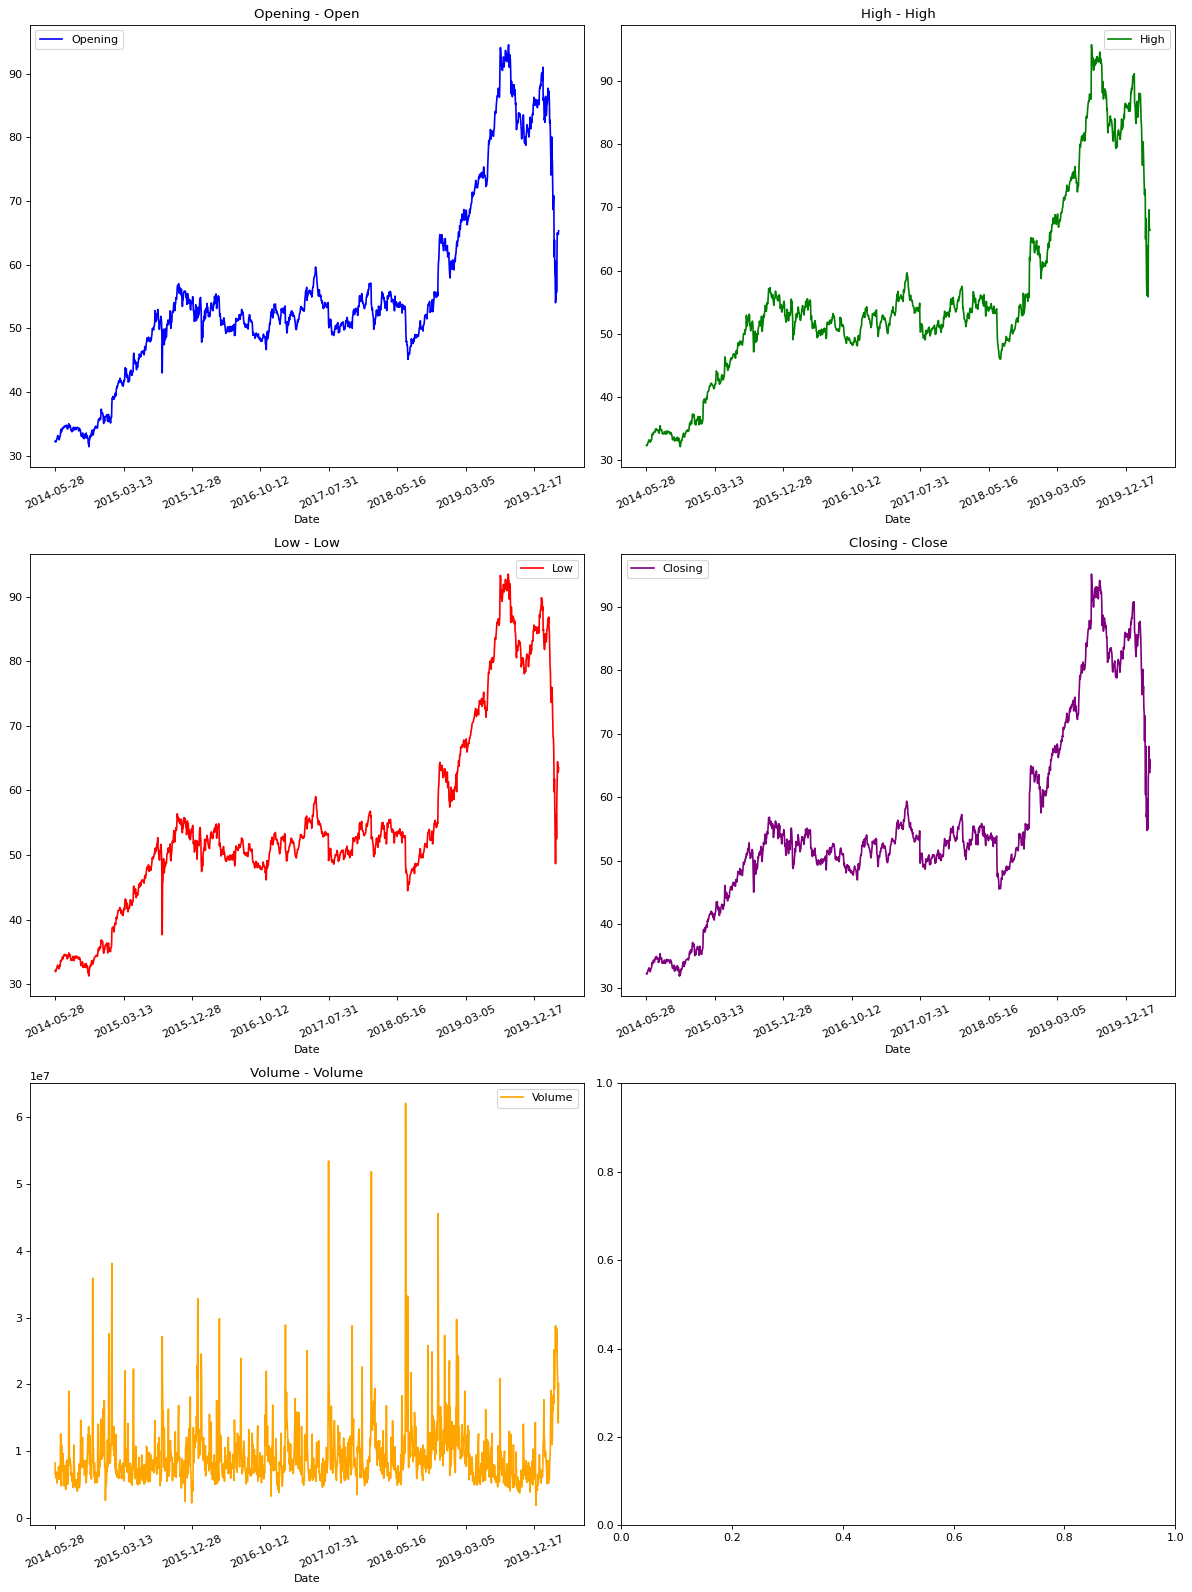

In [7]:
show_raw_visualization(df_train)

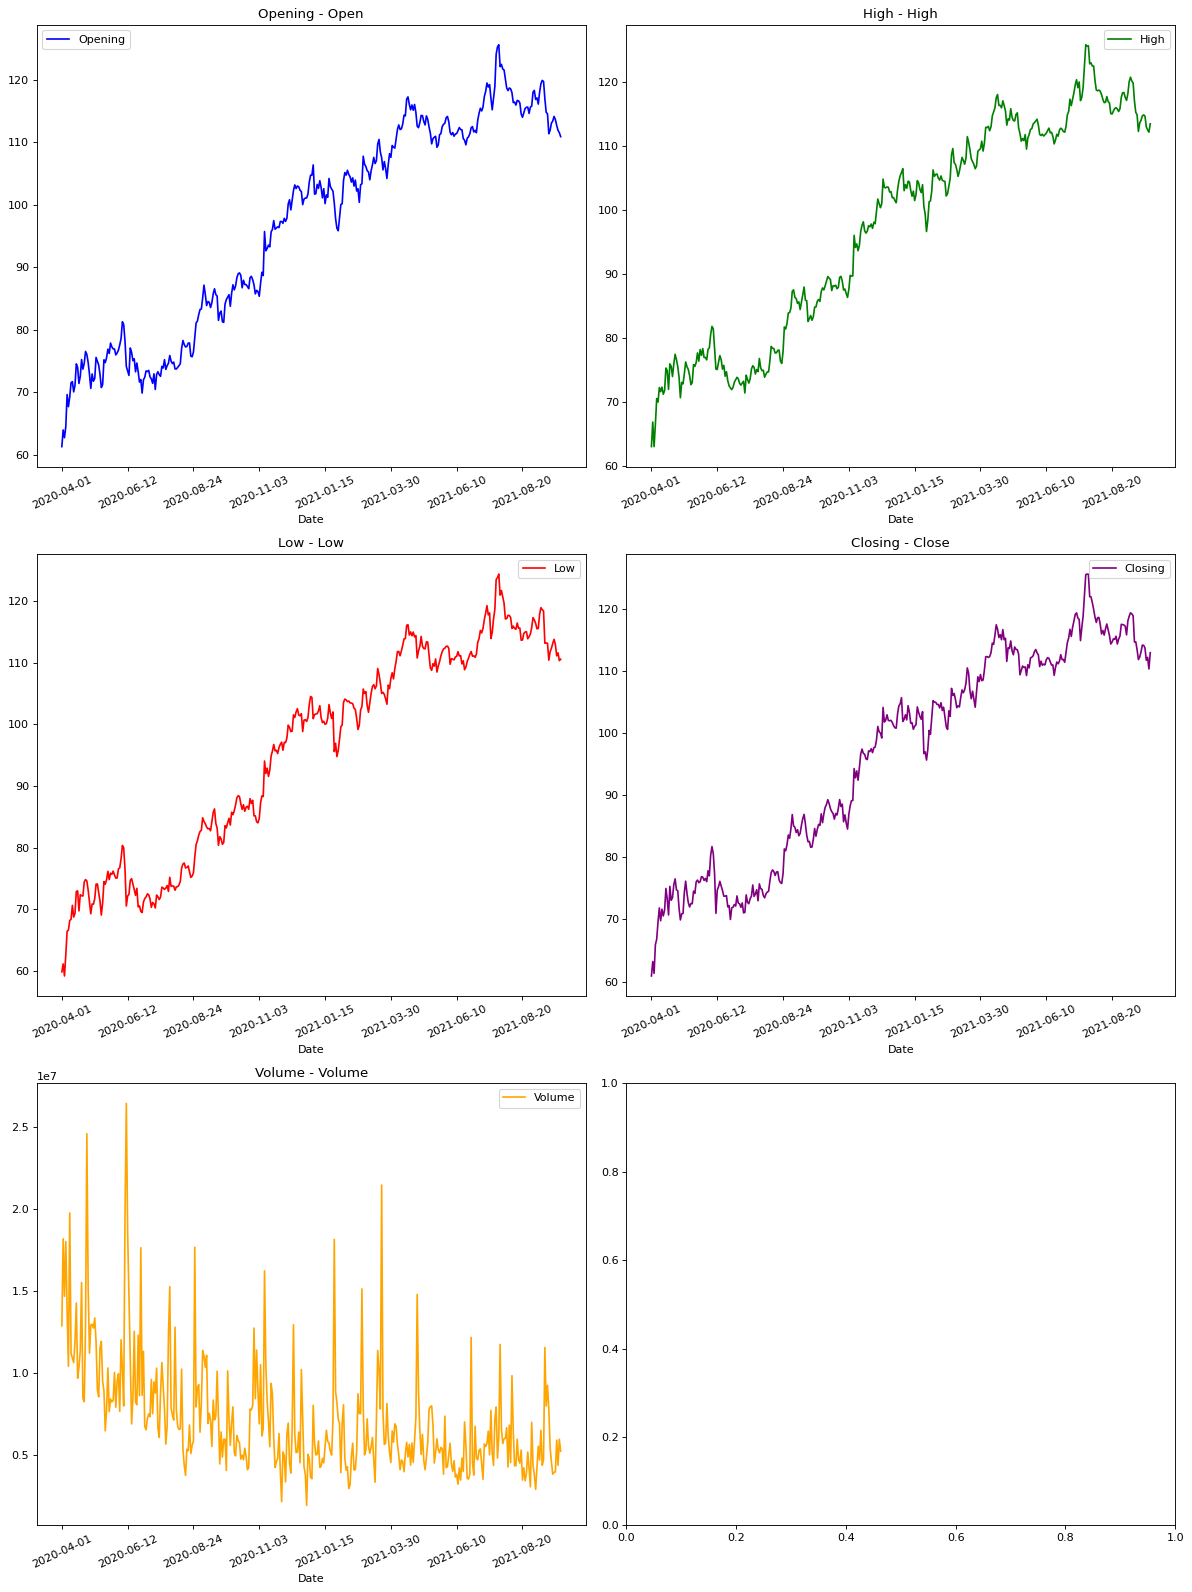

In [8]:
show_raw_visualization(df_test)

## Feature Scaling

In [9]:
scaler = MinMaxScaler(feature_range=(0, 1))

train = df_train.drop(columns=["Date"], axis=1)
train = scaler.fit_transform(train)

df_train_scaled = pd.concat([df_train["Date"].reset_index(drop=True), pd.DataFrame(train, columns=df.columns[1:]).reset_index(drop=True)], axis=1)

test = df_test.drop(columns=["Date"], axis=1)
test = scaler.transform(test)

df_test_scaled = pd.concat([df_test["Date"].reset_index(drop=True), pd.DataFrame(test, columns=df.columns[1:]).reset_index(drop=True)], axis=1)

## Create Dataset

### Train

In [11]:
start = 0
end = len(df_train_scaled) - 30

x_train = df_train_scaled.loc[:end][feature_keys]
y_train = df_train_scaled.loc[end:][['Open', 'Close', 'High', 'Low', 'Volume']]

sequence_length = len(y_train) 

In [12]:
ds_train = tf.keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

2024-05-04 12:39:13.874182: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-04 12:39:13.927990: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-04 12:39:13.928066: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-04 12:39:13.931266: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-05-04 12:39:13.931387: I external/local_xla/xla/stream_executor

In [13]:
len(x_train), len(y_train)

(1443, 30)

### Test

In [14]:
x_end = len(df_test_scaled) - future

x_val = df_test_scaled.loc[:x_end][feature_keys]
y_val = df_test_scaled.loc[x_end:][['Open', 'Close', 'High', 'Low', 'Volume']]

ds_val = tf.keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

In [15]:
for inputs, targets in ds_train.take(1):
    print("Input shape:", inputs.numpy().shape)
    print("Target shape:", targets.numpy().shape)

Input shape: (16, 30, 5)
Target shape: (16, 5)


# Modelling

In [16]:
def create_model(time_steps, num_features):
    i = Input(shape=(time_steps, num_features))
    x = LSTM(units=20, return_sequences=True)(i)
    x = Dropout(0.2)(x)
    x = LSTM(units=20)(x)
    x = Dense(5)(x)
    model = Model(inputs=i, outputs=x)
    return model

In [17]:
Model1 = create_model(30, 5)

In [18]:
Model1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 30, 5)]           0         
                                                                 
 lstm (LSTM)                 (None, 30, 20)            2080      
                                                                 
 dropout (Dropout)           (None, 30, 20)            0         
                                                                 
 lstm_1 (LSTM)               (None, 20)                3280      
                                                                 
 dense (Dense)               (None, 5)                 105       
                                                                 
Total params: 5465 (21.35 KB)
Trainable params: 5465 (21.35 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
Model1.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error", metrics=['mean_squared_error'])

In [20]:
checkpointer = ModelCheckpoint(filepath = 'weights_best.hdf5', verbose = 1, save_best_only = True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
his=Model1.fit(ds_train, epochs=epochs, validation_data=ds_val, batch_size=batch_size,callbacks=[checkpointer, early_stopping])

Epoch 1/1000


2024-05-04 12:39:42.387566: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-05-04 12:39:43.773927: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fbc513e0430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-05-04 12:39:43.773986: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2024-05-04 12:39:43.780163: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


1/2 [==============>...............] - ETA: 5s - loss: 0.4436 - mean_squared_error: 0.4436

I0000 00:00:1714801183.981438   79531 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_loss improved from inf to 1.41724, saving model to weights_best.hdf5
2/2 [==============================] - 6s 986ms/step - loss: 0.3293 - mean_squared_error: 0.3293 - val_loss: 1.4172 - val_mean_squared_error: 1.4172
Epoch 2/1000
1/2 [==============>...............] - ETA: 0s - loss: 0.4309 - mean_squared_error: 0.4309

/home/wbchn/miniconda3/envs/TensorFlow-DLN/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_loss improved from 1.41724 to 1.35386, saving model to weights_best.hdf5
2/2 [==============================] - 0s 177ms/step - loss: 0.3180 - mean_squared_error: 0.3180 - val_loss: 1.3539 - val_mean_squared_error: 1.3539
Epoch 3/1000
1/2 [==============>...............] - ETA: 0s - loss: 0.4177 - mean_squared_error: 0.4177
Epoch 3: val_loss improved from 1.35386 to 1.28643, saving model to weights_best.hdf5
2/2 [==============================] - 0s 143ms/step - loss: 0.3063 - mean_squared_error: 0.3063 - val_loss: 1.2864 - val_mean_squared_error: 1.2864
Epoch 4/1000
1/2 [==============>...............] - ETA: 0s - loss: 0.4038 - mean_squared_error: 0.4038
Epoch 4: val_loss improved from 1.28643 to 1.21457, saving model to weights_best.hdf5
2/2 [==============================] - 0s 228ms/step - loss: 0.2938 - mean_squared_error: 0.2938 - val_loss: 1.2146 - val_mean_squared_error: 1.2146
Epoch 5/1000
1/2 [==============>...............] - ETA: 0s - loss: 0.3877 - mean_squa

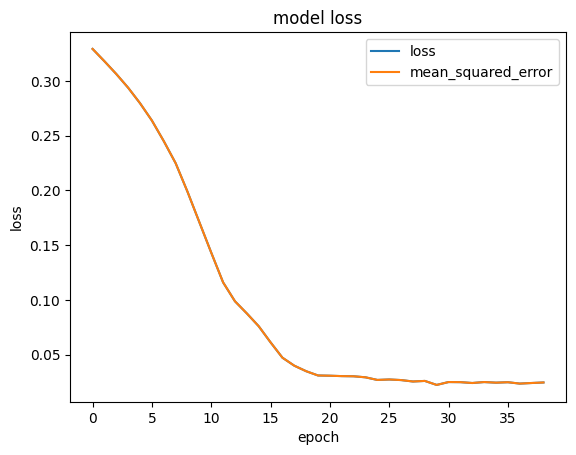

In [21]:
plt.plot(his.history['loss'])
plt.plot(his.history['mean_squared_error'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss','mean_squared_error'], loc='upper right')
plt.show()

In [34]:
preds = np.array([])

for x, y in ds_val:
    preds = np.append(preds, Model1.predict(x))


preds = scaler.inverse_transform(preds.reshape(-1, 5))

1/1 [==============================] - 0s 33ms/step


In [36]:
preds_df = pd.DataFrame(preds, columns=['Open', 'Close', 'High', 'Low', 'Volume'])

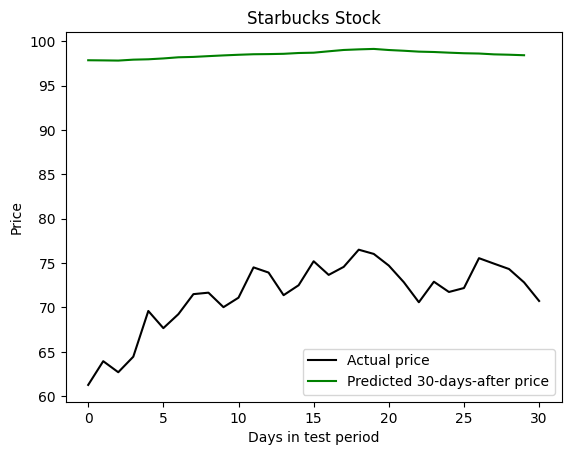

In [49]:
plt.plot(df_test.reset_index(drop=True).loc[0:30]['Open'], color='black', label=f"Actual price")
plt.plot(preds_df['Open'], color= 'green', label=f"Predicted 30-days-after price")
plt.title(f"Starbucks Stock")
plt.xlabel("Days in test period")
plt.ylabel(f"Price")
plt.legend()
plt.show()